In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import FloatSlider, interact
from numpy.random import Philox
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary
from qiskit.synthesis.two_qubit import TwoQubitWeylDecomposition
from qiskit.visualization import plot_bloch_vector
from qiskit.visualization.state_visualization import _bloch_multivector_data
from qutip import Qobj, sigmax, sigmay, sigmaz, tensor
from scipy.linalg import expm
from weylchamber import c1c2c3
from can_sandwich.bgate import BGate
from tqdm.notebook import tqdm

In [2]:
def canonicalize_circuit(current_gate):
    return TwoQubitWeylDecomposition(current_gate, fidelity=1.0).circuit(
        euler_basis="U3"
    )


def canonicalize(current_gate):
    return Operator(canonicalize_circuit(current_gate)).data


SxSx = tensor(sigmax(), sigmax()).full()
SySy = tensor(sigmay(), sigmay()).full()
SzSz = tensor(sigmaz(), sigmaz()).full()


def canonical_gate(a, b, c):
    return expm(np.array(1j * (a * SxSx + b * SySy + c * SzSz)))

In [3]:
Qobj(Operator(canonicalize_circuit(CXGate())))

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 7.07106781e-01-7.07106781e-01j -2.54742760e-18+7.79796604e-17j
   5.55111512e-17+1.11022302e-16j -1.18927248e-16-1.34211813e-17j]
 [-8.37585589e-17-5.09485519e-18j  1.66533454e-16+1.66533454e-16j
   7.28848052e-17+1.02274595e-16j  7.07106781e-01-7.07106781e-01j]
 [-5.55111512e-17+1.66533454e-16j -8.37585589e-17-6.20110514e-17j
   7.07106781e-01-7.07106781e-01j  2.42949351e-17+1.29116958e-16j]
 [ 1.24022103e-16+7.79796604e-17j  7.07106781e-01-7.07106781e-01j
  -7.03373776e-17-4.02635440e-17j  1.66533454e-16+2.22044605e-16j]]

In [ ]:
# op = random_unitary(4).to_matrix()
# u3a, u3b, u3c = canonicalize_circuit(Operator(b_sandwich(op)))[0].params

In [5]:
def _recover_local_equivalence(target_gate, current_gate):
    decomp1 = TwoQubitWeylDecomposition(target_gate)
    decomp2 = TwoQubitWeylDecomposition(current_gate)
    local_coords1 = np.array([decomp1.a, decomp1.b, decomp1.c])
    local_coords2 = np.array([decomp2.a, decomp2.b, decomp2.c])
    if not np.all(np.isclose(np.abs(local_coords1 - local_coords2), np.zeros(3))):
        if not np.isclose(np.abs(decomp1.c), np.abs(decomp2.c)):
            raise ValueError("input gates are not locally equivalent")
    k1 = np.matrix(decomp2.K2r).getH() @ decomp1.K2r
    k2 = np.matrix(decomp2.K2l).getH() @ decomp1.K2l
    k3 = decomp1.K1r @ np.matrix(decomp2.K1r).getH()
    k4 = decomp1.K1l @ np.matrix(decomp2.K1l).getH()
    global_phase = decomp1.global_phase - decomp2.global_phase
    return k1, k2, k3, k4, global_phase


def recover_equivalent_circuit(target_gate, current_gate):
    k1, k2, k3, k4, global_phase = _recover_local_equivalence(target_gate, current_gate)
    temp = QuantumCircuit(2, global_phase=global_phase)
    temp.append(UnitaryGate(k1), [0])
    temp.append(UnitaryGate(k2), [1])
    temp.append(current_gate, [0, 1])
    temp.append(UnitaryGate(k3), [0])
    temp.append(UnitaryGate(k4), [1])
    return temp

In [ ]:
UnitaryGate(expm(0.5 * 1j / 2 * sigmay().full()))

Instruction(name='unitary', num_qubits=1, num_clbits=0, params=[array([[ 0.96891242+0.j,  0.24740396+0.j],
       [-0.24740396+0.j,  0.96891242+0.j]])])

In [6]:
def b_sandwich(target, local_equiv=False):
    # https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.93.020502
    target_decomp = TwoQubitWeylDecomposition(target, fidelity=1.0)
    c1, c2, c3 = target_decomp.a, target_decomp.b, target_decomp.c
    rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
    )
    b2 = np.arcsin(rb2)
    temp = QuantumCircuit(2)
    temp.append(BGate(), [0, 1])
    # temp.append(UnitaryGate(expm(c1 * 1j * sigmay().full())), [0])
    # temp.append(UnitaryGate(expm(b2 * 1j / 2 * sigmaz().full())), [1])
    # temp.append(UnitaryGate(expm(b1 * 1j / 2 * sigmay().full())), [1])
    # temp.append(UnitaryGate(expm(b2 * 1j / 2 * sigmaz().full())), [1])
    temp.ry(-2 * c1, 0)
    temp.rz(-b2, 1)
    temp.ry(-b1, 1)
    temp.rz(-b2, 1)
    temp.append(BGate(), [0, 1])

    if local_equiv:
        return recover_equivalent_circuit(target, Operator(temp))
    return temp


# t = b_sandwich(CXGate(), False)

  0%|          | 0/400 [00:00<?, ?it/s]

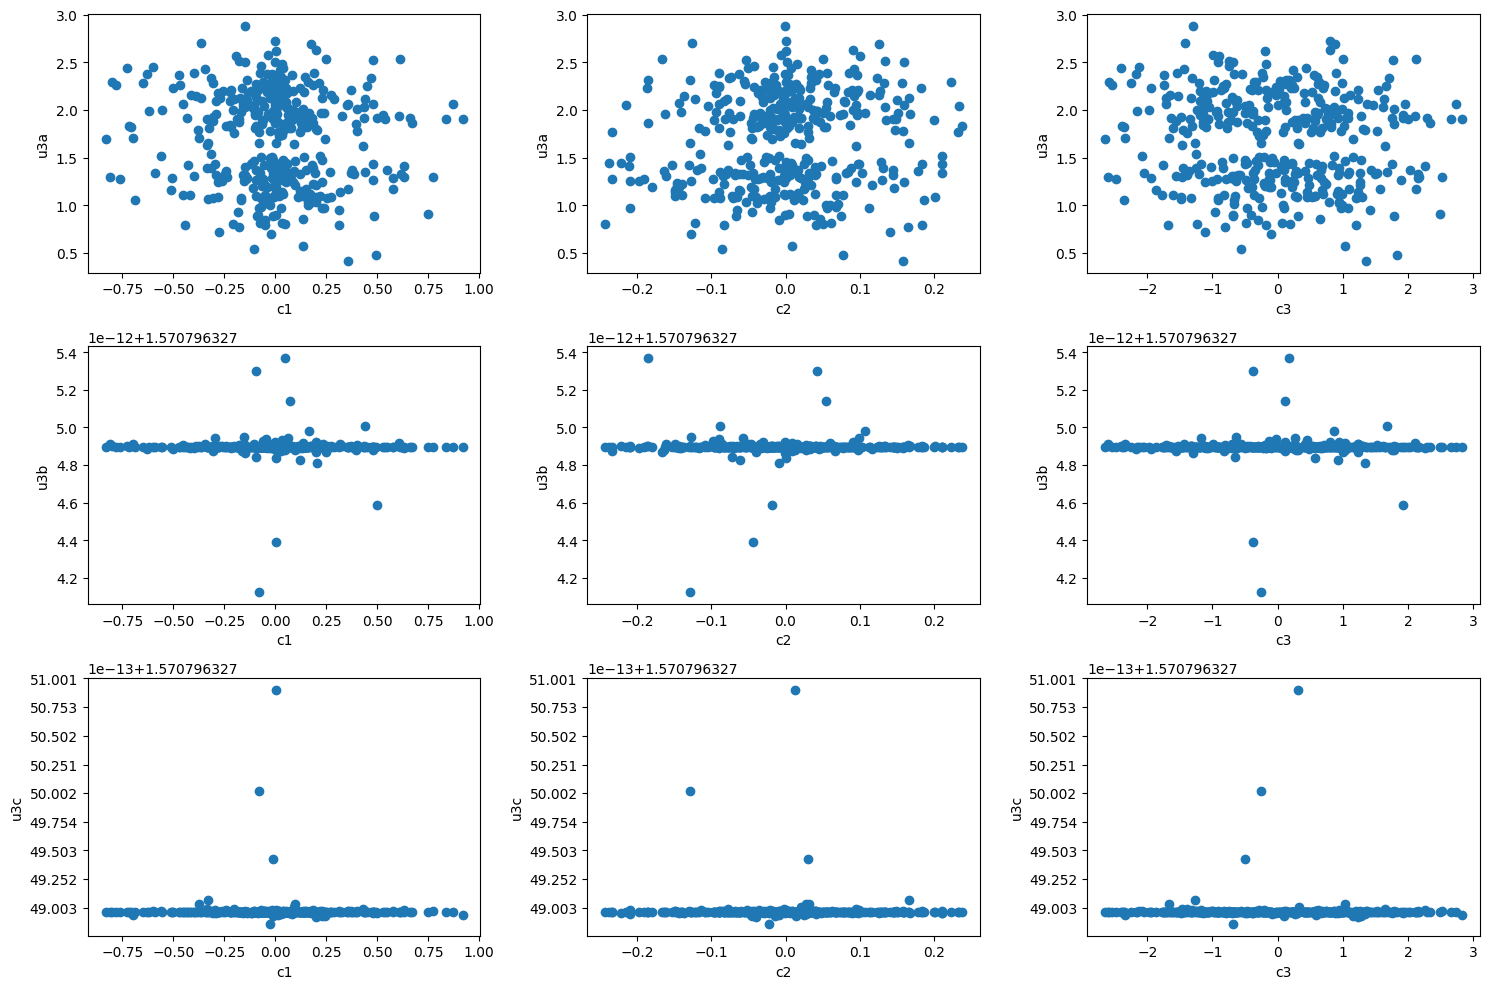

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from weylchamber import g1g2g3_from_c1c2c3

# Assuming you have the canonical_gate, b_sandwich, and canonicalize_circuit functions defined

# Lists to store the values of c1, c2, c3 and u3 parameters
c1_vals, c2_vals, c3_vals = [], [], []
u3a_vals, u3b_vals, u3c_vals = [], [], []

for _ in tqdm(range(400)):
    # Random c1, c2, c3 values
    c1, c2, c3 = np.random.rand(3) * 2 * np.pi

    # Generate the random canonical gate
    gate = canonical_gate(c1, c2, c3)
    c1, c2, c3 = g1g2g3_from_c1c2c3(c1, c2, c3)

    # Perform the b sandwich decomposition
    b_sand = b_sandwich(gate)

    # Investigate K1l u3 parameters
    u3_params = canonicalize_circuit(Operator(b_sand))[1].params
    u3a, u3b, u3c = np.abs(u3_params)

    # Append the results to the lists
    c1_vals.append(c1)
    c2_vals.append(c2)
    c3_vals.append(c3)
    u3a_vals.append(u3a)
    u3b_vals.append(u3b)
    u3c_vals.append(u3c)

# Now, plot each u3 parameter as a function of c1, c2, and c3
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

# Plot u3a against c1, c2, c3
axes[0, 0].scatter(c1_vals, u3a_vals)
axes[0, 0].set_xlabel("c1")
axes[0, 0].set_ylabel("u3a")

axes[0, 1].scatter(c2_vals, u3a_vals)
axes[0, 1].set_xlabel("c2")
axes[0, 1].set_ylabel("u3a")

axes[0, 2].scatter(c3_vals, u3a_vals)
axes[0, 2].set_xlabel("c3")
axes[0, 2].set_ylabel("u3a")

# Plot u3b against c1, c2, c3
axes[1, 0].scatter(c1_vals, u3b_vals)
axes[1, 0].set_xlabel("c1")
axes[1, 0].set_ylabel("u3b")

axes[1, 1].scatter(c2_vals, u3b_vals)
axes[1, 1].set_xlabel("c2")
axes[1, 1].set_ylabel("u3b")

axes[1, 2].scatter(c3_vals, u3b_vals)
axes[1, 2].set_xlabel("c3")
axes[1, 2].set_ylabel("u3b")

# Plot u3c against c1, c2, c3
axes[2, 0].scatter(c1_vals, u3c_vals)
axes[2, 0].set_xlabel("c1")
axes[2, 0].set_ylabel("u3c")

axes[2, 1].scatter(c2_vals, u3c_vals)
axes[2, 1].set_xlabel("c2")
axes[2, 1].set_ylabel("u3c")

axes[2, 2].scatter(c3_vals, u3c_vals)
axes[2, 2].set_xlabel("c3")
axes[2, 2].set_ylabel("u3c")

plt.tight_layout()
plt.show()

In [77]:
Qobj(b1)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.21992053e-16+1.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  5.55111512e-17+1.40658018e-16j]
 [ 0.00000000e+00+0.00000000e+00j -1.32613651e-16+1.00000000e+00j
   0.00000000e+00+1.15015210e-16j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+1.15015210e-16j
  -1.32613651e-16-1.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [-5.55111512e-17+1.40658018e-16j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  1.21992053e-16-1.00000000e+00j]]

In [78]:
Qobj(Operator(b1_can))

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.00000000e+00  1.11022302e-16 -1.69953884e-33  1.88686715e-49]
 [-1.11022302e-16  1.00000000e+00  5.66060146e-49 -1.69953884e-33]
 [ 1.69953884e-33 -1.88686715e-49 -1.00000000e+00 -1.11022302e-16]
 [-5.66060146e-49  1.69953884e-33  1.11022302e-16 -1.00000000e+00]]

(0.0, 0.0, 0.0)


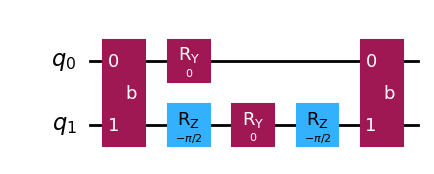

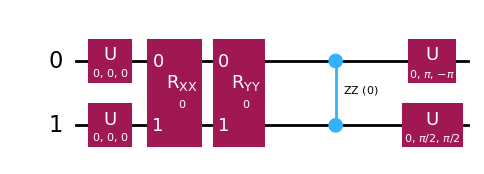

In [79]:
u = np.eye(4)
print(c1c2c3(u))
b1 = Operator(b_sandwich(u))
display(b_sandwich(u).draw("mpl"))
b1_can = canonicalize_circuit(b1)
b1_can.draw("mpl")

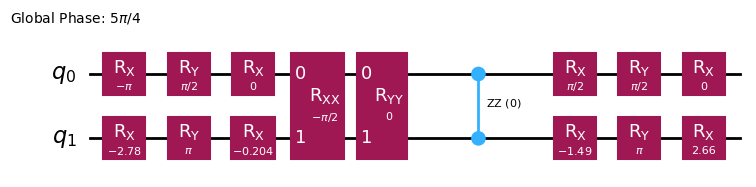

In [ ]:
kak.circuit().draw("mpl")

In [ ]:
kak

TwoQubitWeylDecomposition.from_bytes(
    # TwoQubitWeylDecomposition [specialization=ControlledEquiv] (
    # 	global phase: 5π/4
    # 	       ┌──────────┐ ┌────────┐┌────────────┐ ┌─────────┐  ┌─────────┐
    # 	q_0: ──┤ Ry(-π/2) ├─┤ Rx(-π) ├┤0           ├─┤ Rx(π/2) ├──┤ Ry(π/2) ├
    # 	     ┌─┴──────────┴┐├───────┬┘│  Rxx(-π/2) │┌┴─────────┴─┐└┬───────┬┘
    # 	q_1: ┤ Rx(-2.5802) ├┤ Ry(π) ├─┤1           ├┤ Rx(2.1322) ├─┤ Ry(π) ├─
    # 	     └─────────────┘└───────┘ └────────────┘└────────────┘ └───────┘
    # )
    b'k05VTVBZAQB2AHsnZGVzY3InOiAnPGMxNicsICdmb3J0cmFuX29yZGVyJzogRmFsc2UsICdzaGFw'
    b'ZSc6ICg0LCA0KSwgfSAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAg'
    b'ICAgICAgICAgICAgIAoAAAAAAADwPwAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
    b'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
    b'AAAAAAAAAAAAAAAAAAAAAAAA8D8AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
    b'AAAAAAAAAAAA8D8AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

In [ ]:
from qiskit.circuit.library import RYGate, RXGate

# RYGate(-np.pi/2).to_matrix() @ RXGate(-np.pi).to_matrix()
RXGate(2.1322).to_matrix() @ RYGate(np.pi).to_matrix()

array([[ 2.96083868e-17-8.75321353e-01j, -4.83541651e-01-5.35979747e-17j],
       [ 4.83541651e-01-5.35979747e-17j,  2.96083868e-17+8.75321353e-01j]])

In [ ]:
kak = TwoQubitWeylDecomposition(cz, fidelity=1.0)
k12 = np.matrix(np.kron(kak.K2r, kak.K2l)).getH()
k34 = np.matrix(np.kron(kak.K1r, kak.K1l)).getH()
Qobj(k12 @ cz @ k34)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-3.06161700e-17-5.00000000e-01j -5.00000000e-01+1.35917284e-16j
  -5.00000000e-01-2.48949813e-17j  8.61273212e-17-5.00000000e-01j]
 [ 8.04061325e-17+5.00000000e-01j  5.00000000e-01-8.61273212e-17j
  -5.00000000e-01-8.61273212e-17j  2.48949813e-17-5.00000000e-01j]
 [ 8.61273212e-17+5.00000000e-01j -5.00000000e-01+1.35917284e-16j
   5.00000000e-01+8.04061325e-17j  8.61273212e-17-5.00000000e-01j]
 [ 1.35917284e-16+5.00000000e-01j -5.00000000e-01+8.61273212e-17j
  -5.00000000e-01-1.41638472e-16j -2.48949813e-17+5.00000000e-01j]]

In [ ]:
cz

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]])

In [ ]:
Qobj()

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.00000000e+00  3.05311332e-16 -1.11022302e-16  1.38777878e-17]
 [-1.52655666e-16 -1.00000000e+00  4.16333634e-17 -1.11022302e-16]
 [ 1.11022302e-16  2.97505198e-32 -1.00000000e+00 -1.52655666e-16]
 [-1.38777878e-17 -2.22044605e-16 -2.91433544e-16  1.00000000e+00]]

In [ ]:
k12 = np.matrix(np.kron(kak.K2r, kak.K2l))
k34 = np.matrix(np.kron(kak.K1r, kak.K1l))
Qobj(k12 @ Operator(kak.circuit()).data @ k34)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-5.00000000e-01-5.00000000e-01j  3.84597957e-16+2.81640995e-17j
  -2.73575654e-16-8.28582029e-17j -5.00000000e-01+5.00000000e-01j]
 [ 3.76532616e-17-1.10613779e-16j -5.00000000e-01-5.00000000e-01j
  -5.00000000e-01+5.00000000e-01j -4.26231320e-16-1.66124930e-16j]
 [-2.40071711e-16-1.00307569e-16j -5.00000000e-01+5.00000000e-01j
  -5.00000000e-01-5.00000000e-01j  7.11916496e-16-1.00307569e-16j]
 [-5.00000000e-01+5.00000000e-01j -3.92727377e-16-1.14185356e-16j
   3.92727377e-16-2.25207659e-16j -5.00000000e-01-5.00000000e-01j]]

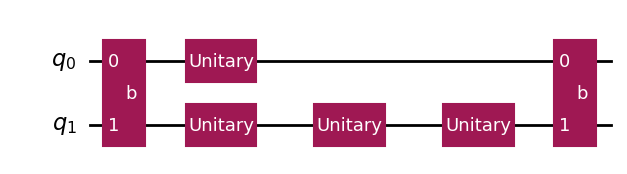

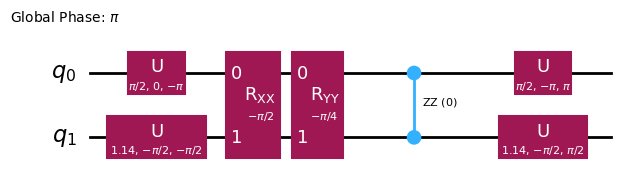

In [ ]:
a, b, c = np.pi / 4, np.pi / 8, 0
display(b_sandwich(canonical_gate(a, b, c)).draw("mpl"))
canonicalize_circuit(Operator(b_sandwich(canonical_gate(a, b, c)))).draw("mpl")

In [ ]:
c1, c2, c3 = 1, 0, 0
rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
b1 = np.arccos(rb1)
rb2 = np.sqrt(
    np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
)
b2 = np.arcsin(rb2)
print(c1, b1, b2)

1 0.0 1.5707963267948966


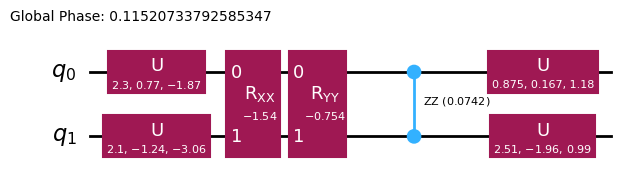

In [ ]:
canonicalize_circuit(
    canonical_gate(0.5, 1.25, 0.9)
    @ Operator(b_sandwich(canonical_gate(a, b, c))).data
    @ canonical_gate(0.2, 0.3, 1.4)
).draw("mpl")

In [ ]:
def b_sandwich(target, recover_left=True, recover_right=True):
    # https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.93.020502
    target_decomp = TwoQubitWeylDecomposition(target, fidelity=1.0)
    c1, c2, c3 = target_decomp.a, target_decomp.b, target_decomp.c
    rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
    )
    b2 = np.arcsin(rb2)
    temp = QuantumCircuit(2)
    temp.append(BGate(), [0, 1])
    temp.append(UnitaryGate(expm(c1 * 1j * sigmay().full())), [0])
    temp.append(UnitaryGate(expm(b2 * 1j / 2 * sigmaz().full())), [1])
    temp.append(UnitaryGate(expm(b1 * 1j / 2 * sigmay().full())), [1])
    temp.append(UnitaryGate(expm(b2 * 1j / 2 * sigmaz().full())), [1])
    temp.append(BGate(), [0, 1])

    local_equiv = recover_equivalent_circuit(target, Operator(temp))
    temp2 = QuantumCircuit(2)

    if recover_left and recover_right:
        return local_equiv

    elif recover_left:
        for op, qargs, cargs in local_equiv[:-2]:  # remove last two gates
            temp2.append(op, qargs, cargs)
            return temp2
    elif recover_right:
        for op, qargs, cargs in local_equiv[2:]:  # remove first two gates
            temp2.append(op, qargs, cargs)
            return temp2
    return temp


def b_sandwich_recursive(target, depth=0, recover_left=False, recover_right=False):
    # we want to take each B gate in the sandwich decomposition and
    # instead of using BGate() definition, use BGate itself decomposed using sandwich decomposition
    # however, Bgates that are in the middle of the circuit need to be exactly same for it to work
    # which means we can drop first gates only for the first BGate (left most in some recursive call tree)
    # and we can drop the last gates on for the right most in the recursive call tree
    if depth == 0:
        return b_sandwich(target)

    target_decomp = TwoQubitWeylDecomposition(target, fidelity=1.0)
    c1, c2, c3 = target_decomp.a, target_decomp.b, target_decomp.c
    rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
    )
    b2 = np.arcsin(rb2)
    temp = QuantumCircuit(2)
    temp.append(
        b_sandwich_recursive(
            BGate(), depth - 1, recover_left=recover_left, recover_right=True
        ),
        [0, 1],
    )
    temp.append(UnitaryGate(expm(c1 * 1j * sigmay().full())), [0])
    temp.append(UnitaryGate(expm(b2 * 1j / 2 * sigmaz().full())), [1])
    temp.append(UnitaryGate(expm(b1 * 1j / 2 * sigmay().full())), [1])
    temp.append(UnitaryGate(expm(b2 * 1j / 2 * sigmaz().full())), [1])
    temp.append(
        b_sandwich_recursive(
            BGate(), depth - 1, recover_left=True, recover_right=recover_right
        ),
        [0, 1],
    )

In [ ]:
Qobj(Operator(b_sandwich(Operator(b_sandwich(BGate())))).data)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 9.23879533e-01-2.96625298e-16j  5.55111512e-17-3.72944021e-16j
   3.72361331e-16+3.33066907e-16j -6.79035858e-17+3.82683432e-01j]
 [-3.33066907e-16-4.16499368e-16j  3.82683432e-01+4.65529010e-16j
   3.84340779e-16+9.23879533e-01j -2.68326114e-16+2.22044605e-16j]
 [ 4.90733560e-16+3.33066907e-16j -1.59010667e-16+9.23879533e-01j
   3.82683432e-01-5.51541176e-16j  2.77555756e-17-3.02248610e-16j]
 [-5.44404220e-18+3.82683432e-01j  1.94530766e-16-8.32667268e-17j
  -3.33066907e-16+2.87497407e-16j  9.23879533e-01+3.97639041e-16j]]

In [ ]:
Qobj(Operator(b_sandwich(BGate(), False, False)).data)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 3.00424186e-17+8.65201608e-01j  2.12431979e-17+2.70598050e-01j
  -3.24005507e-01+3.00424186e-17j  2.70598050e-01+8.31504133e-17j]
 [-7.03290092e-17-2.70598050e-01j -8.66388345e-17+3.24005507e-01j
   2.70598050e-01+7.25288143e-17j  8.65201608e-01+8.13280350e-17j]
 [ 3.24005507e-01-6.09960263e-17j  2.70598050e-01+8.09506081e-17j
  -3.00424186e-17-8.65201608e-01j  9.37720122e-17+2.70598050e-01j]
 [ 2.70598050e-01+7.25288143e-17j -8.65201608e-01-5.12856164e-17j
  -7.25288143e-17-2.70598050e-01j  5.56852268e-17-3.24005507e-01j]]

In [ ]:
Qobj(Operator(b_sandwich_recursive(BGate(), 1)).data)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-1.68045313e-16+8.65201608e-01j  1.19634256e-16+2.70598050e-01j
  -3.24005507e-01+6.35276807e-17j  2.70598050e-01+2.13854538e-16j]
 [ 2.22458308e-16-2.70598050e-01j  3.52029509e-16+3.24005507e-01j
   2.70598050e-01-2.89119765e-17j  8.65201608e-01-3.59532180e-17j]
 [ 3.24005507e-01+3.13721416e-16j  2.70598050e-01+4.49794297e-16j
  -2.64660931e-16-8.65201608e-01j -1.54390494e-16+2.70598050e-01j]
 [ 2.70598050e-01+3.76144628e-16j -8.65201608e-01-8.09542379e-16j
  -3.92252163e-16-2.70598050e-01j  5.33402344e-16-3.24005507e-01j]]

In [ ]:
random_target = random_unitary(4)
random_target = iSwapGate()
can_target = canonicalize(random_target)
L = canonical_gate(np.pi / 4, np.pi / 8, 0.0)  # arbitrary
R = canonical_gate(np.pi / 4, np.pi / 8, 0.0)  # arbitrary
ltr = Operator(np.matrix(L).getH() @ can_target @ np.matrix(R).getH())
Td = recover_equivalent_circuit(Operator(b_sandwich(ltr)), UnitaryGate(ltr))

In [ ]:
Operator(Td).equiv(b_sandwich(ltr))

True

In [ ]:
c1c2c3(random_target)

(0.5, 0.5, 0.0)

In [ ]:
c1c2c3(L @ Operator(Td).data @ R)

(1.0, 0.0, 0.0)

In [ ]:
left = L @ Operator(ktk).data @ R

In [ ]:
c1c2c3(left)

(0.59545296, 0.19383379, 0.06003154)

In [ ]:
c1c2c3(L @ Operator(b_sandwich(Operator(ktk))).data @ R)

(0.59545296, 0.19383379, 0.06003154)

In [ ]:
Qobj(Operator(ktk).data)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.12004122+0.0898508j  -0.09256963+0.45097551j  0.7884456 -0.09256963j
  -0.34776918+0.12004122j]
 [ 0.09256963-0.45097551j -0.12004122+0.78538917j -0.34776918+0.12004122j
   0.11350542-0.09256963j]
 [-0.7884456 +0.09256963j -0.34776918+0.12004122j -0.12004122-0.0898508j
  -0.09256963+0.45097551j]
 [-0.34776918+0.12004122j -0.11350542+0.09256963j  0.09256963-0.45097551j
   0.12004122-0.78538917j]]

In [ ]:
Qobj(Operator(b_sandwich(Operator(ktk))).data)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.12004122+0.0898508j  -0.09256963+0.45097551j  0.7884456 -0.09256963j
  -0.34776918+0.12004122j]
 [ 0.09256963-0.45097551j -0.12004122+0.78538917j -0.34776918+0.12004122j
   0.11350542-0.09256963j]
 [-0.7884456 +0.09256963j -0.34776918+0.12004122j -0.12004122-0.0898508j
  -0.09256963+0.45097551j]
 [-0.34776918+0.12004122j -0.11350542+0.09256963j  0.09256963-0.45097551j
   0.12004122-0.78538917j]]

In [ ]:
# a, b, c = 0.1, 0.2, 1.2
# u = TwoQubitWeylDecomposition(
#     Operator(b_sandwich(canonical_gate(a, b, c))), fidelity=1.0
# ).K1l
# state = u @ np.array([1, 0])
# plot_bloch_multivector(state)

interactive(children=(FloatSlider(value=0.1, description='a', max=6.283185307179586, step=0.01), FloatSlider(v…

<function __main__.update_bloch_multivectors(a, b, c)>

In [ ]:
# Qobj(canonicalize(BGate()))
Qobj(BGate())  # equiv

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.92387953+0.j         0.        +0.j         0.        +0.j
  0.        +0.38268343j]
 [0.        +0.j         0.38268343+0.j         0.        +0.92387953j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.92387953j 0.38268343+0.j
  0.        +0.j        ]
 [0.        +0.38268343j 0.        +0.j         0.        +0.j
  0.92387953+0.j        ]]

In [ ]:
Qobj(canonicalize(CXGate()))

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.00000000e+00 -1.23856400e-16 -1.33846115e-16 -2.74886568e-16]
 [ 2.48044206e-16  2.79711185e-17 -2.89352415e-32  1.00000000e+00]
 [ 7.78722482e-17 -2.39717880e-16  1.00000000e+00 -7.05177566e-17]
 [ 2.17128215e-32  1.00000000e+00  2.48044206e-16  1.45597049e-17]]

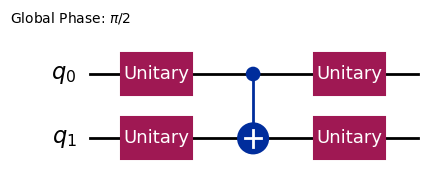

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.00000000e+00 -2.04435566e-16 -5.55111512e-17 -2.46519033e-32]
 [ 1.28631342e-16  1.00000000e+00  1.54074396e-32  1.11022302e-16]
 [ 0.00000000e+00 -2.46519033e-32  1.00000000e+00  1.84142493e-16]
 [ 1.23259516e-32  1.66533454e-16  1.48924414e-16 -1.00000000e+00]]

In [ ]:
qc = recover_equivalent_circuit(CZGate(), CXGate())
display(qc.draw("mpl"))
Qobj(Operator(qc).data)